In [5]:
# ==========================================
# STUDENTS AI USAGE DATA ANALYSIS
# Using Pandas, NumPy, SciPy, and Matplotlib
# ==========================================

# Import libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [6]:
# ==========================================
# 1. LOAD DATASET (PANDAS)
# ==========================================

df = pd.read_excel("students_ai_usage.xlsx")

In [7]:
# Display first five rows
print("First Five Records")
print(df.head())

First Five Records
   age education_level  study_hours_per_day uses_ai ai_tools_used  \
0   19         college                  1.4      No           NaN   
1   15          school                  3.9     Yes       Copilot   
2   15          school                  1.9     Yes       Copilot   
3   15          school                  2.8      No           NaN   
4   19         college                  2.7      No           NaN   

  purpose_of_ai  grades_before_ai  grades_after_ai  daily_screen_time_hours  
0           NaN                62               62                        3  
1      Research                56               61                        2  
2      Homework                75               88                        5  
3           NaN                55               55                        3  
4           NaN                59               59                        3  


In [8]:
# ==========================================
# 2. DATA INFORMATION (PANDAS)
# ==========================================

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      100 non-null    int64  
 1   education_level          100 non-null    object 
 2   study_hours_per_day      100 non-null    float64
 3   uses_ai                  100 non-null    object 
 4   ai_tools_used            40 non-null     object 
 5   purpose_of_ai            40 non-null     object 
 6   grades_before_ai         100 non-null    int64  
 7   grades_after_ai          100 non-null    int64  
 8   daily_screen_time_hours  100 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 7.2+ KB
None

Missing Values
age                         0
education_level             0
study_hours_per_day         0
uses_ai                     0
ai_tools_used              60
purpose_of_ai              60
grades_before_ai   

In [9]:
# ==========================================
# 3. DESCRIPTIVE STATISTICS
#    (PANDAS + NUMPY)
# ==========================================

print("\nDescriptive Statistics")
print(df.describe())


Descriptive Statistics
              age  study_hours_per_day  grades_before_ai  grades_after_ai  \
count  100.000000           100.000000         100.00000       100.000000   
mean    16.490000             2.987000          64.77000        68.700000   
std      1.702612             1.145713           6.16909         8.140806   
min     14.000000             1.000000          55.00000        55.000000   
25%     15.000000             1.975000          59.00000        61.000000   
50%     16.000000             2.800000          63.00000        69.000000   
75%     18.000000             4.025000          70.00000        74.000000   
max     19.000000             5.000000          75.00000        89.000000   

       daily_screen_time_hours  
count               100.000000  
mean                  4.340000  
std                   1.793479  
min                   2.000000  
25%                   3.000000  
50%                   4.000000  
75%                   6.000000  
max               

In [12]:
# Number of students
total_students = len(df)

In [13]:
# Students using AI
ai_users = df[df['uses_ai'] == 'Yes']

In [14]:
# Students not using AI
non_ai_users = df[df['uses_ai'] == 'No']

print("\nTotal Students:", total_students)
print("AI Users:", len(ai_users))
print("Non-AI Users:", len(non_ai_users))


Total Students: 100
AI Users: 40
Non-AI Users: 60


In [15]:
# ==========================================
# 4. NUMPY CALCULATIONS
# ==========================================

average_age = np.mean(df['age'])
average_study_hours = np.mean(df['study_hours_per_day'])

print("\nAverage Age:", round(average_age, 2))
print("Average Study Hours:",
      round(average_study_hours, 2))


Average Age: 16.49
Average Study Hours: 2.99


In [16]:
# Grades before and after AI
before_mean = np.mean(ai_users['grades_before_ai'])
after_mean = np.mean(ai_users['grades_after_ai'])

print("\nAverage Grade Before AI:",
      round(before_mean, 2))
print("Average Grade After AI:",
      round(after_mean, 2))


Average Grade Before AI: 65.32
Average Grade After AI: 75.15


In [17]:
# Grade improvement
improvement = after_mean - before_mean

print("Average Improvement:",
      round(improvement, 2))

Average Improvement: 9.83


In [18]:
# ==========================================
# 5. SCIPY STATISTICAL TEST
# ==========================================

t_statistic, p_value = stats.ttest_rel(
    ai_users['grades_before_ai'],
    ai_users['grades_after_ai']
)

print("\nPaired Sample T-Test")
print("T-statistic:", t_statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant Difference Found")
else:
    print("No Significant Difference Found")


Paired Sample T-Test
T-statistic: -17.498935674294867
P-value: 4.585463872841295e-20
Significant Difference Found


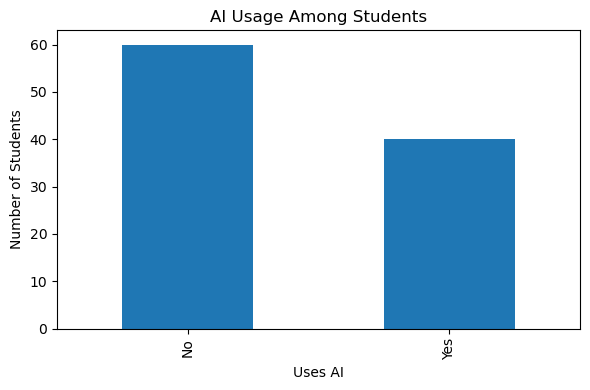

In [19]:
# ==========================================
# 6. MATPLOTLIB VISUALIZATION
# ==========================================

# AI Usage Bar Chart
plt.figure(figsize=(6,4))

df['uses_ai'].value_counts().plot(kind='bar')

plt.title('AI Usage Among Students')
plt.xlabel('Uses AI')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()

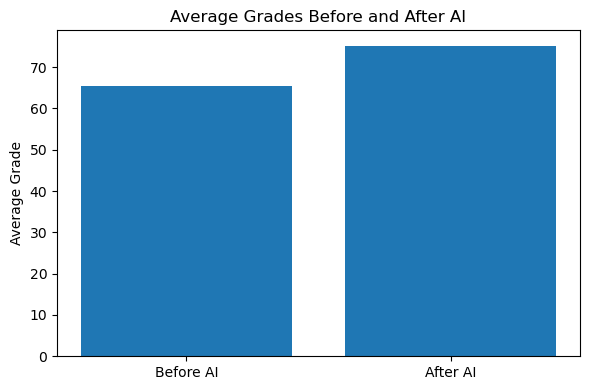

In [20]:
# ==========================================
# 7. GRADES BEFORE VS AFTER AI
# ==========================================

plt.figure(figsize=(6,4))

means = [
    ai_users['grades_before_ai'].mean(),
    ai_users['grades_after_ai'].mean()
]

labels = ['Before AI', 'After AI']

plt.bar(labels, means)

plt.title('Average Grades Before and After AI')
plt.ylabel('Average Grade')

plt.tight_layout()
plt.show()

In [21]:
# ==========================================
# 8. SAVE RESULTS TO EXCEL
# ==========================================

results = pd.DataFrame({
    'Metric': [
        'Total Students',
        'AI Users',
        'Non-AI Users',
        'Average Age',
        'Average Study Hours',
        'Mean Grade Before AI',
        'Mean Grade After AI',
        'P-value'
    ],
    'Value': [
        total_students,
        len(ai_users),
        len(non_ai_users),
        average_age,
        average_study_hours,
        before_mean,
        after_mean,
        p_value
    ]
})

results.to_excel(
    "analysis_results.xlsx",
    index=False
)

print("\nResults saved successfully!")


Results saved successfully!
